In [1]:
import scvi
from rich import print

In [2]:
DATA_FOLDER: str = "/home/nathanl/Data/cosmx_cortex"
FIGURES_FOLDER: str = "/home/nathanl/scviva_paper/cosmx_brain/figures"

In [3]:
import os

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
from scipy.sparse import csr_matrix

sc.settings.verbosity = 1
sc.settings.figdir = FIGURES_FOLDER
os.makedirs(FIGURES_FOLDER, exist_ok=True)

import colorcet as cc

In [ ]:
import matplotlib.pyplot as plt
# Set SVG font type to 'none' to keep text as text in SVG files
plt.rcParams["svg.fonttype"] = "none"
sc.settings._vector_friendly = True
sc.set_figure_params(dpi=150, fontsize=12, format="svg")

# CosMX Cortex adata

In [4]:
# raw AtoMx export: per-cell metadata + per-cell x per-gene count matrix
meta = pd.read_csv(os.path.join(DATA_FOLDER, "S3_metadata_file.csv"), engine="pyarrow")
expr = pd.read_csv(os.path.join(DATA_FOLDER, "S3_exprMat_file.csv"), engine="pyarrow")

meta = meta.set_index("cell")
expr = expr.set_index("cell")

common_cells = meta.index.intersection(expr.index)
meta = meta.loc[common_cells]
expr = expr.loc[common_cells]

print(meta.shape, expr.shape)

(188686, 79)
(188686, 6624)

In [5]:
# separate real genes from CosMx QC probes (negative controls / SystemControl falsecodes)
non_gene_cols = ["fov", "cell_ID"]
neg_cols = [c for c in expr.columns if c.startswith("NegPrb")]
falsecode_cols = [c for c in expr.columns if c.startswith("FalseCode")]
gene_cols = [c for c in expr.columns if c not in non_gene_cols + neg_cols + falsecode_cols]

adata = ad.AnnData(
    X=csr_matrix(expr[gene_cols].to_numpy(dtype=np.float32)),
    obs=meta.copy(),
    var=pd.DataFrame(index=gene_cols),
)
adata.layers["counts"] = adata.X.copy()
adata.obsm["negative_probes"] = csr_matrix(expr[neg_cols].to_numpy(dtype=np.float32))
adata.uns["negative_probe_names"] = neg_cols

# batch / cell type / spatial coordinates, following this repo's obs-key convention
adata.obs["batch"] = adata.obs["Run_Tissue_name"].astype("category")
adata.obs["cell_type"] = adata.obs["RefinedClusts_Final"].astype("category")
adata.obsm["spatial"] = adata.obs[["CenterX_global_px", "CenterY_global_px"]].to_numpy()

sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)

adata.write_h5ad(os.path.join(DATA_FOLDER, "cosmx_cortex.h5ad"))
print(adata)

AnnData object with n_obs × n_vars = 188686 × 6278
    obs: 'cell_ID', 'nCount_RNA', 'nFeature_RNA', 'nCount_negprobes', 'nFeature_negprobes', 'nCount_falsecode', 
'nFeature_falsecode', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.Histone', 'Max.Histone', 'Mean.G', 
'Max.G', 'Mean.rRNA', 'Max.rRNA', 'Mean.GFAP', 'Max.GFAP', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'assay_type', 
'dualfiles', 'Run_name', 'ISH.concentration', 'Dash', 'tissue', 'slide_ID', 'Run_Tissue_name', 'Panel', 
'assay_type.1', 'version', 'Area.um2', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 
'CenterY_global_px', 'propNegative', 'complexity', 'errorCtEstimate', 'percOfDataFromError', 'qcFlagsRNACounts', 
'qcFlagsCellCounts', 'qcFlagsCellPropNeg', 'qcFlagsCellComplex', 'qcFlagsCellArea', 'qcCellsFlagged', 
'median_negprobes', 'negprobes_quantile_0.9', 'median_RNA', 'RNA_quantile_0.9', 'nCell', 'nCount', 'nCountPerCell',
'nFeaturePerCell', 'propNegativeCellAvg', 'complexityCellAvg', 'errorCtPerCellEstimate', 
'percOfDataFromErrorPerCell', 'qcFlagsFOV', 'RefinedClusts_Final', 'prob', 
'RNA_spatialClusteringNeighbours_astro.1', 'RNA_spatialClusteringNeighbours_astro.2', 
'RNA_spatialClusteringNeighbours_endothelial', 'RNA_spatialClusteringNeighbours_Inh.1', 
'RNA_spatialClusteringNeighbours_Inh.2', 'RNA_spatialClusteringNeighbours_Inh.3', 
'RNA_spatialClusteringNeighbours_L2_3', 'RNA_spatialClusteringNeighbours_L4', 'RNA_spatialClusteringNeighbours_L6',
'RNA_spatialClusteringNeighbours_microglia.1', 'RNA_spatialClusteringNeighbours_microglia.2', 
'RNA_spatialClusteringNeighbours_oligodendrocyte', 'RNA_spatialClusteringNeighbours_OPC', 
'RNA_spatialClusteringNeighbours_unknown', 'spatialClusteringAssignments', 'batch', 'cell_type', 
'n_genes_by_counts', 'total_counts'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'negative_probe_names'
    obsm: 'negative_probes', 'spatial'
    layers: 'counts'

In [6]:
adata.obs.slide_ID.unique()

array([1])

In [7]:
print(f"n_obs (cells): {adata.n_obs}")
print(f"n_vars (genes): {adata.n_vars}")
print(f"n_batches: {adata.obs['batch'].nunique()} -> {list(adata.obs['batch'].cat.categories)}")
print(f"n_fovs: {adata.obs['fov'].nunique()}")
print(f"n_cell_types: {adata.obs['cell_type'].nunique()}")
print()
print("cell type counts:")
print(adata.obs["cell_type"].value_counts())
print()
print("per-cell QC summary:")
adata.obs[["total_counts", "n_genes_by_counts"]].describe()

n_obs (cells): 188686

n_vars (genes): 6278

n_batches: 1 -> ['S3']

n_fovs: 392

n_cell_types: 14

cell type counts:

cell_type
oligodendrocyte    83137
endothelial        17642
L2_3               14449
astro.1            12431
astro.2             9731
microglia.2         8850
L4                  8801
L6                  7609
unknown             7214
Inh.3               6270
OPC                 5747
microglia.1         3177
Inh.1               2715
Inh.2                913
Name: count, dtype: int64

per-cell QC summary:

,total_counts,n_genes_by_counts
count,188686.000000,188686.000000
mean,860.981995,557.294632
std,933.121704,464.681864
min,40.000000,24.000000
25%,310.000000,245.000000
50%,575.000000,424.000000
75%,1008.000000,698.000000
max,13014.000000,3938.000000


In [ ]:
# Gene selection for benchmarking: 5,000 HVGs, seurat_v3 flavor on raw counts.
#
# Run ONCE, before anything else touches the hvg5000 file: the baselines (BANKSY/SimVI),
# runner.py and the region annotation below all write their results INTO that file, so
# regenerating it would wipe them. Hence the existence guard.
HVG_PATH = os.path.join(DATA_FOLDER, "cosmx_cortex_hvg5000.h5ad")
if not os.path.exists(HVG_PATH):
    sc.pp.highly_variable_genes(adata, n_top_genes=5000, flavor="seurat_v3", layer="counts")
    adata[:, adata.var["highly_variable"]].copy().write_h5ad(HVG_PATH)
    print("wrote", HVG_PATH)
else:
    print(HVG_PATH, "already exists - not overwriting (it carries downstream results)")


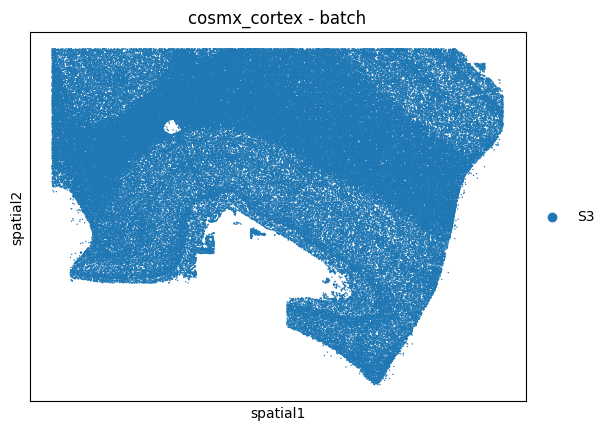

In [8]:
sc.pl.embedding(
    adata,
    basis="spatial",
    color="batch",
    size=4,
    title="cosmx_cortex - batch",
    # save="_cosmx_cortex_batch.png",
)

# annotate regions of interest in the cortex dataset

#play with KMeans k from ... 

In [4]:
adata = sc.read_h5ad(os.path.join(DATA_FOLDER, "cosmx_cortex_hvg5000.h5ad"))
print(adata)

AnnData object with n_obs × n_vars = 188686 × 5000
    obs: 'cell_ID', 'nCount_RNA', 'nFeature_RNA', 'nCount_negprobes', 'nFeature_negprobes', 'nCount_falsecode', 
'nFeature_falsecode', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.Histone', 'Max.Histone', 'Mean.G', 
'Max.G', 'Mean.rRNA', 'Max.rRNA', 'Mean.GFAP', 'Max.GFAP', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'assay_type', 
'dualfiles', 'Run_name', 'ISH.concentration', 'Dash', 'tissue', 'slide_ID', 'Run_Tissue_name', 'Panel', 
'assay_type.1', 'version', 'Area.um2', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 
'CenterY_global_px', 'propNegative', 'complexity', 'errorCtEstimate', 'percOfDataFromError', 'qcFlagsRNACounts', 
'qcFlagsCellCounts', 'qcFlagsCellPropNeg', 'qcFlagsCellComplex', 'qcFlagsCellArea', 'qcCellsFlagged', 
'median_negprobes', 'negprobes_quantile_0.9', 'median_RNA', 'RNA_quantile_0.9', 'nCell', 'nCount', 'nCountPerCell',
'nFeaturePerCell', 'propNegativeCellAvg', 'complexityCellAvg', 'errorCtPerCellEstimate', 
'percOfDataFromErrorPerCell', 'qcFlagsFOV', 'RefinedClusts_Final', 'prob', 
'RNA_spatialClusteringNeighbours_astro.1', 'RNA_spatialClusteringNeighbours_astro.2', 
'RNA_spatialClusteringNeighbours_endothelial', 'RNA_spatialClusteringNeighbours_Inh.1', 
'RNA_spatialClusteringNeighbours_Inh.2', 'RNA_spatialClusteringNeighbours_Inh.3', 
'RNA_spatialClusteringNeighbours_L2_3', 'RNA_spatialClusteringNeighbours_L4', 'RNA_spatialClusteringNeighbours_L6',
'RNA_spatialClusteringNeighbours_microglia.1', 'RNA_spatialClusteringNeighbours_microglia.2', 
'RNA_spatialClusteringNeighbours_oligodendrocyte', 'RNA_spatialClusteringNeighbours_OPC', 
'RNA_spatialClusteringNeighbours_unknown', 'spatialClusteringAssignments', 'batch', 'cell_type', 
'n_genes_by_counts', 'total_counts', '_scvi_batch', '_scvi_labels', 'index', 'niche_cluster', 'region'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mt', 'highly_variable', 
'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_to_int', 'hvg', 'log1p', 'negative_probe_names', 
'niche_cluster_colors', 'region_colors'
    obsm: 'X_banksy_02_harmony', 'banksy_pc_20_lambda_0.2', 'banksy_pc_20_nonspatial', 'negative_probes', 
'neighborhood_composition', 'niche_distances', 'niche_indexes', 'qz1_m_niche_ct', 'simvi25_all_mae_50', 
'simvi25_both_mae_50', 'simvi25_interact_mae_50', 'simvi25_intrinsic_mae_50', 'spatial'
    layers: 'counts'

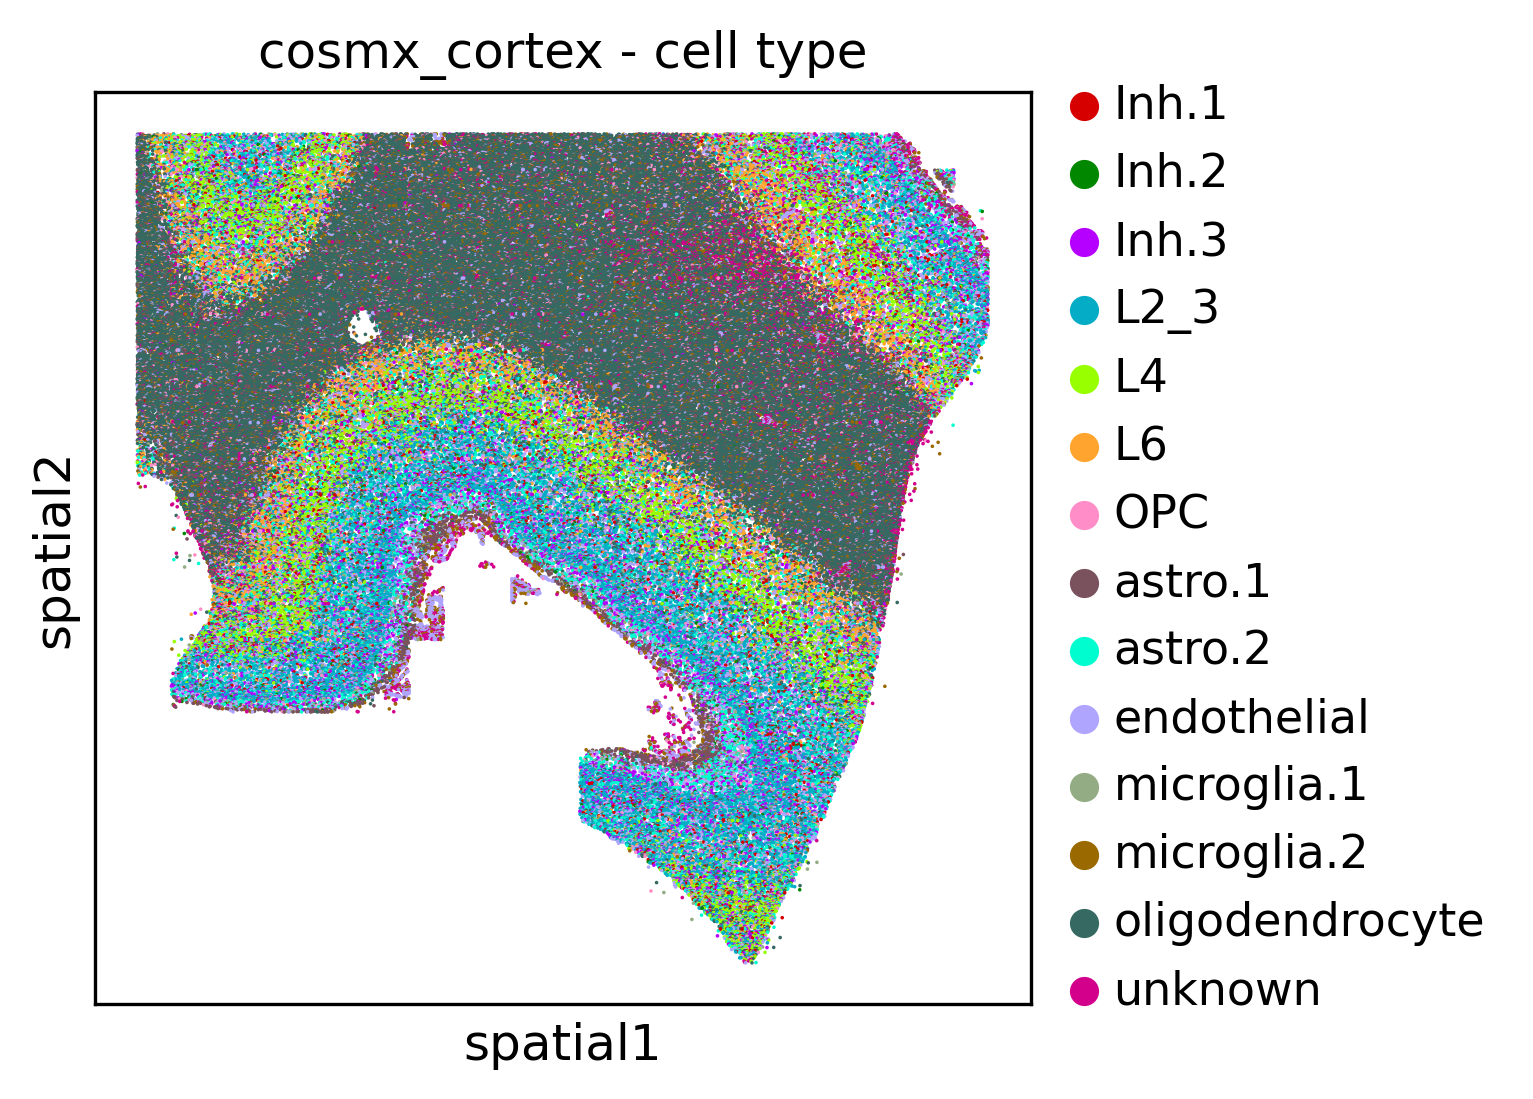

In [11]:
sc.pl.embedding(
    adata,
    basis="spatial",
    color="cell_type",
    size=3,
    palette=cc.glasbey_light,
    title="cosmx_cortex - cell type",
    # save="_cosmx_cortex_cell_type.png",
    show=False,
)

plt.savefig(
    os.path.join(FIGURES_FOLDER, "cortex_cell_types.svg"),
    bbox_inches="tight",
    dpi=500,
)
plt.savefig(
    os.path.join(FIGURES_FOLDER, "cortex_cell_types.png"),
    bbox_inches="tight",
    dpi=500,
)

In [5]:
adata.obs.cell_type.value_counts()

cell_type
oligodendrocyte    83137
endothelial        17642
L2_3               14449
astro.1            12431
astro.2             9731
microglia.2         8850
L4                  8801
L6                  7609
unknown             7214
Inh.3               6270
OPC                 5747
microglia.1         3177
Inh.1               2715
Inh.2                913
Name: count, dtype: int64

In [12]:
setup_kwargs = {
    "sample_key": "batch",
    "labels_key": "cell_type",
    "cell_coordinates_key": "spatial",
    "expression_embedding_key": "spatial",
    "expression_embedding_niche_key": "qz1_m_niche_ct",
    "niche_composition_key": "neighborhood_composition",
    "niche_indexes_key": "niche_indexes",
    "niche_distances_key": "niche_distances",
}
import scvi

scvi.external.SCVIVA.preprocessing_anndata(
    adata,
    k_nn=20,
    **setup_kwargs,
)

Saved niche_indexes and niche_distances in adata.obsm

Saved neighborhood_composition in adata.obsm

Saved qz1_m_niche_ct in adata.obsm

In [13]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

# Get the neighborhood composition matrix
X = adata.obsm["neighborhood_composition"]

# Run 5-Means clustering
kmeans = KMeans(n_clusters=5, random_state=42)
adata.obs["niche_cluster"] = kmeans.fit_predict(X)

adata.obs["niche_cluster"] = adata.obs["niche_cluster"].astype("category")

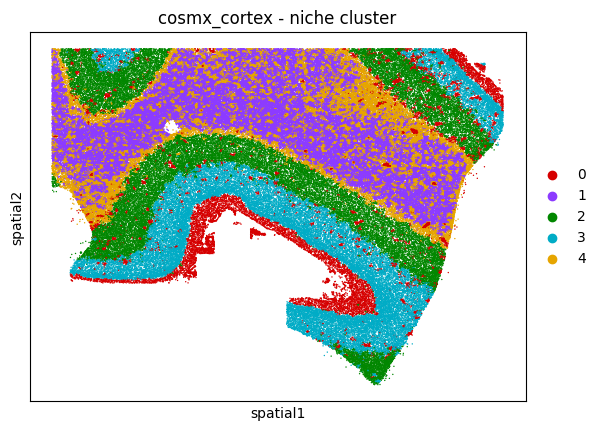

In [9]:
sc.pl.embedding(
    adata,
    basis="spatial",
    color="niche_cluster",
    size=4,
    palette=cc.glasbey_dark,
    title="cosmx_cortex - niche cluster",
    # save="_cosmx_cortex_niche_cluster.png",
)

endo-rich is vessel or peri-vascular

In [14]:
# Make a DataFrame of the matrix
comp_df = pd.DataFrame(X, index=adata.obs_names, columns=adata.obsm["neighborhood_composition"].columns)

# Add the cluster labels
comp_df["niche_cluster"] = adata.obs["niche_cluster"]

# Average composition per cluster
mean_composition = comp_df.groupby("niche_cluster").mean()

# Show results sorted for each cluster
for cluster_id, row in mean_composition.iterrows():
    print(f"\nCluster {cluster_id} average composition:")
    display(row.sort_values(ascending=False).head(10))

/tmp/ipykernel_543494/907464249.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_composition = comp_df.groupby("niche_cluster").mean()


Cluster 0 average composition:

endothelial        0.301696
astro.2            0.115917
astro.1            0.102518
unknown            0.091458
microglia.2        0.080002
oligodendrocyte    0.073842
Inh.3              0.065021
OPC                0.036212
microglia.1        0.035435
L2_3               0.033363
Name: 0, dtype: float64

Cluster 1 average composition:

oligodendrocyte    0.789516
astro.1            0.079522
microglia.2        0.049990
endothelial        0.027818
unknown            0.023290
OPC                0.019199
L6                 0.006235
Inh.3              0.002281
Inh.2              0.000937
microglia.1        0.000435
Name: 1, dtype: float64

...

L4                 0.219370
L6                 0.145184
oligodendrocyte    0.118393
endothelial        0.117110
astro.2            0.113256
Inh.3              0.059757
L2_3               0.050546
OPC                0.040926
Inh.1              0.036936
microglia.1        0.036112
Name: 2, dtype: float64

Cluster 3 average composition:

L2_3               0.402411
endothelial        0.140412
astro.2            0.124250
Inh.3              0.093730
oligodendrocyte    0.051651
microglia.1        0.040463
Inh.1              0.040435
OPC                0.037928
L4                 0.025375
L6                 0.018253
Name: 3, dtype: float64

Cluster 4 average composition:

oligodendrocyte    0.556024
astro.1            0.126559
microglia.2        0.089740
endothelial        0.077865
unknown            0.068349
OPC                0.031801
L6                 0.028729
Inh.3              0.006131
astro.2            0.005418
microglia.1        0.003308
Name: 4, dtype: float64

region
White Matter                    108746
Deep Cortical Layers (L4/L6)     34638
Upper Cortical Layers (L2/3)     30293
Vessel / Peri-Vascular           15009
Name: count, dtype: int64

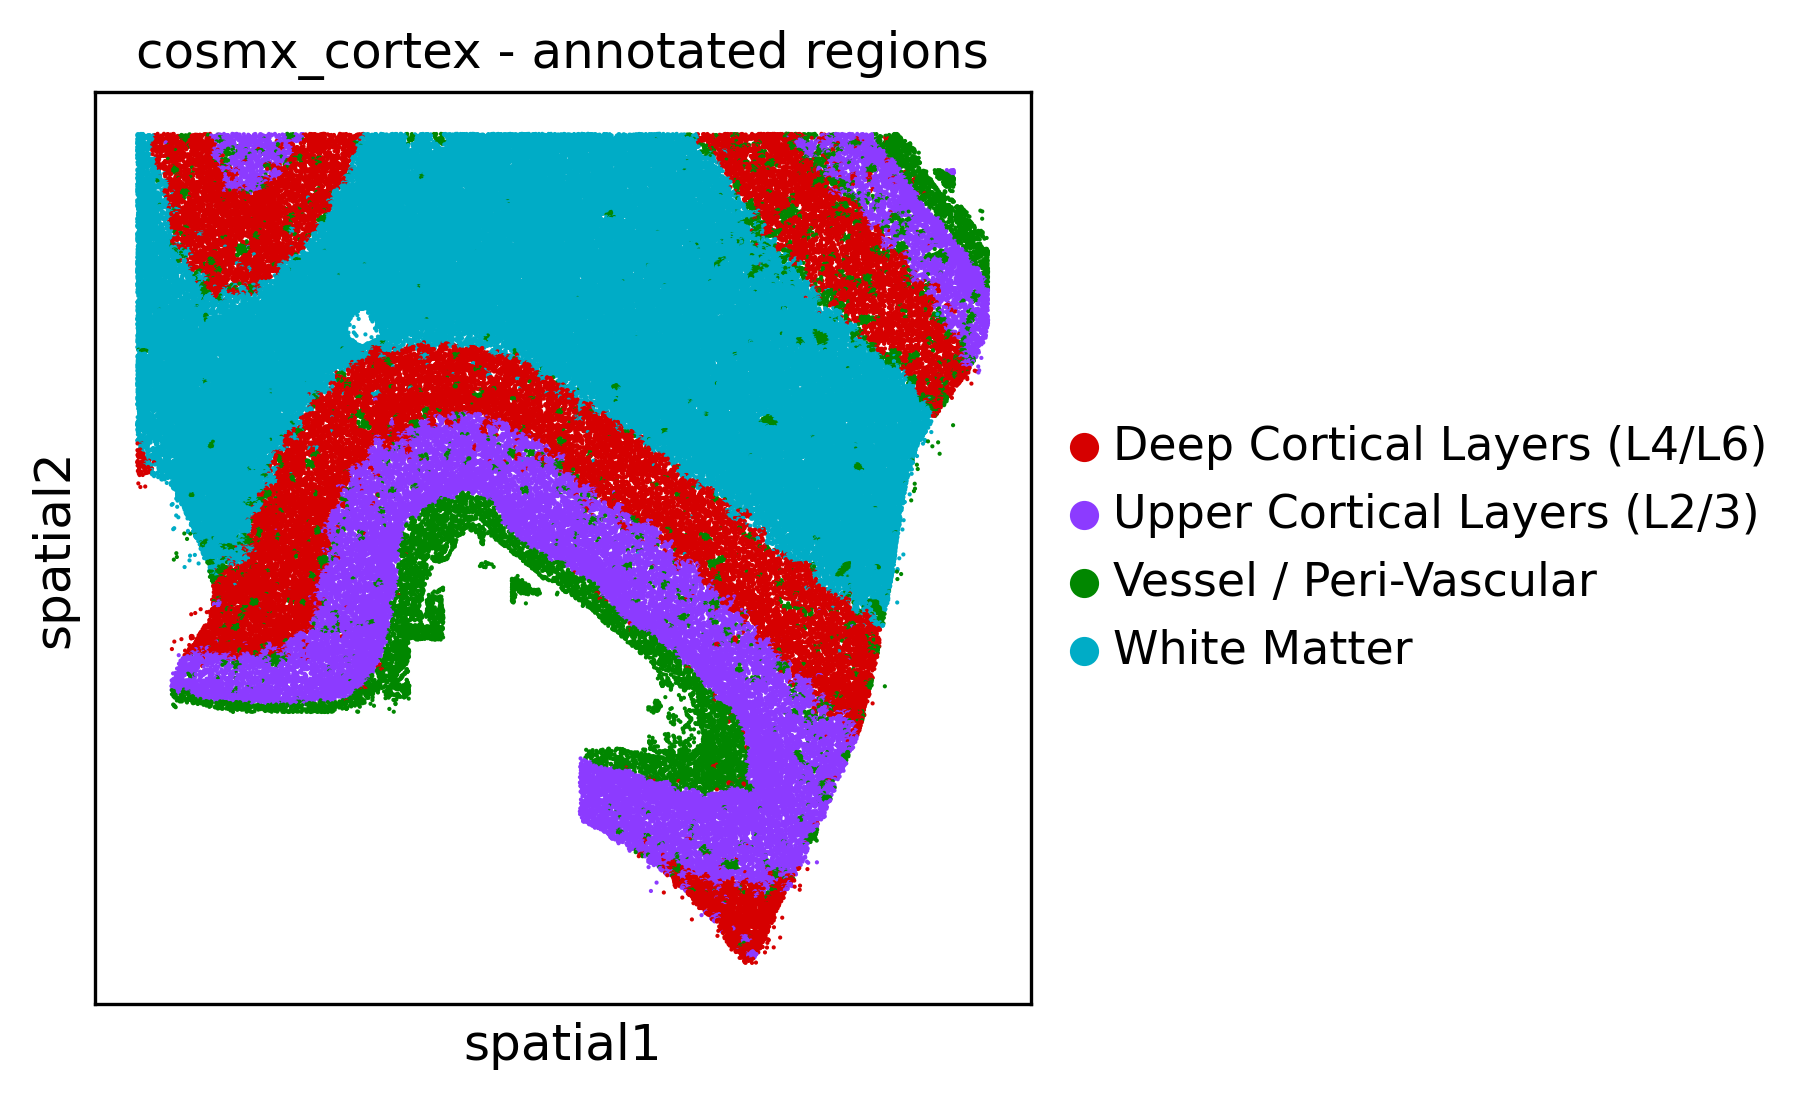

In [15]:
REGION_MAP = {
    "0": "Vessel / Peri-Vascular",
    "1": "White Matter",
    "4": "White Matter",  # merged with cluster 1 - both oligodendrocyte-dominated (79% / 56%)
    "2": "Deep Cortical Layers (L4/L6)",
    "3": "Upper Cortical Layers (L2/3)",
}

adata.obs["region"] = adata.obs["niche_cluster"].astype(str).map(REGION_MAP).astype("category")

print(adata.obs["region"].value_counts())

sc.pl.embedding(
    adata,
    basis="spatial",
    color="region",
    size=4,
    palette=cc.glasbey_dark,
    title="cosmx_cortex - annotated regions",
    show=False,
)

plt.savefig(
    os.path.join(FIGURES_FOLDER, "cortex_regions.svg"),
    bbox_inches="tight",
    dpi=500,
)
plt.savefig(
    os.path.join(FIGURES_FOLDER, "cortex_regions.png"),
    bbox_inches="tight",
    dpi=500,
)

In [13]:
adata.obs["counts_per_cell"] = adata.layers["counts"].sum(axis=1)
adata.obs["counts_per_cell"].min()

np.float32(14.0)

In [12]:
adata.write_h5ad(os.path.join(DATA_FOLDER, "cosmx_cortex_hvg5000.h5ad"))